## Comparison of L2reg old std and new

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.globals as gl
import matplotlib.pyplot as plt
from scipy import stats

#### Loading Evaluation of new L2reg Global Models

In [2]:
methods = ['L2reg']
train_ds_list = gl.get_ldo_names()
eval_ds_list = gl.datasets
eval_ds_names = [ds if gl.sessions[i] == 'all' else ds + gl.sessions[i].split('-')[1] for i, ds in enumerate(gl.datasets)]
df_all = pd.DataFrame()
for i, (ds_code, ds_eval) in enumerate(zip(train_ds_list, eval_ds_names)):
    df_old = rm.comb_eval(models=[ds_code+"-global-Cavg-old"],methods=methods,eval_data=[ds_eval],cerebellum='MNISymC3')
    df_old['fix_std'] = False
    df_new = rm.comb_eval(models=[ds_code+"-global-Cavg"],methods=methods,eval_data=[ds_eval],cerebellum='MNISymC3')
    df_new['fix_std'] = True
    df_all = pd.concat([df_all, df_old, df_new], ignore_index=True)
df_all['logalpha'] = df_all['logalpha'].fillna(-5)
df_all.model = 'Global'

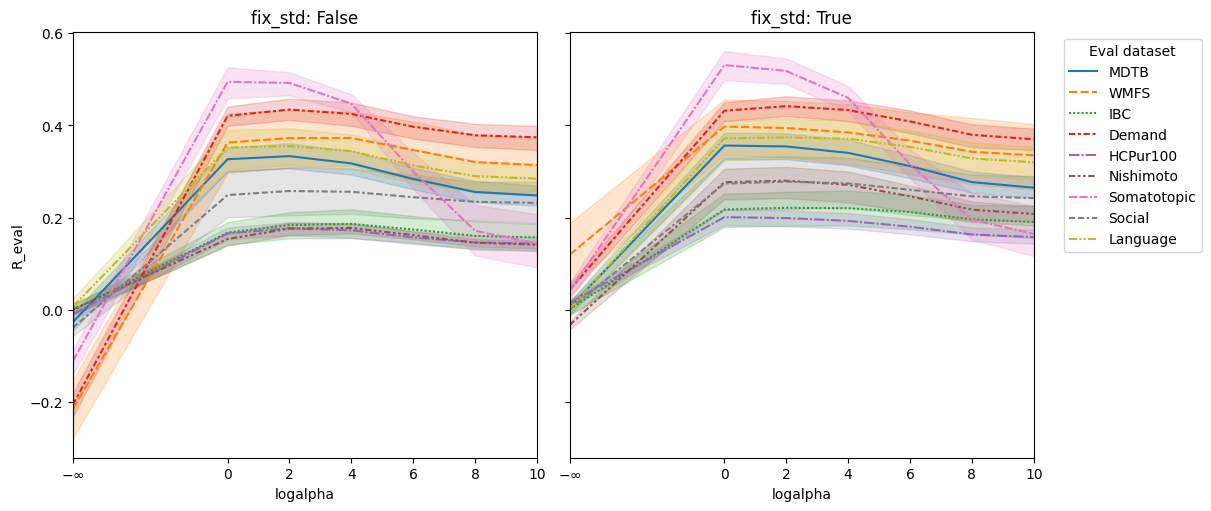

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey='row', constrained_layout=True)
for i, fix_std in enumerate([False, True]):
    sns.lineplot(data=df_all[df_all['fix_std']==fix_std], y='R_eval', x='logalpha',
                hue='eval_dataset', style='eval_dataset',
                hue_order=eval_ds_list, style_order=eval_ds_list, ax=axes[i])
    axes[i].set_title(f"fix_std: {fix_std}")
    if i == 0:
        axes[i].legend_.remove()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Eval dataset');

xticks = df_all['logalpha'].unique()
xticklabels = [r"$-\infty$" if np.isclose(t, -5) else str(int(t)) for t in xticks]
for i in range(2):
    axes[i].set_xticks(xticks)
    axes[i].set_xticklabels(xticklabels)
    axes[i].set_xlim([-5, 10]);

#### Finding best log alpha

In [4]:
for fix_std in [False, True]:
    print(f'\nFix_std: {fix_std}')
    df_std = df_all[df_all['fix_std'] == fix_std]
    A = pd.pivot_table(df_std, index=['model'], columns=['logalpha'], values=['R_eval'], aggfunc='mean')#.reindex(train_ds_list)
    display(A)
    B = np.nan_to_num(A.values)
    ind = B.argmax(axis=1)
    log_a = np.array(A.columns.get_level_values(1)[ind])
    bestla = pd.DataFrame(log_a, index=A.index, columns=['best_logalpha'])
    display(bestla)
    df_all.loc[df_std.index, 'isbest'] = df_std['logalpha'].values == bestla.loc[df_std['model']].values.flatten()
df_best = df_all[df_all['isbest']]


Fix_std: False


R_eval                                                           
logalpha     -5.0       0.0       2.0      4.0       6.0       8.0       10.0
model                                                                        
Global   -0.072252  0.290736  0.300752  0.29301  0.265786  0.243763  0.238438

,best_logalpha
model,
Global,2.0



Fix_std: True


R_eval                                                           
logalpha     -5.0       0.0      2.0       4.0       6.0       8.0       10.0
model                                                                        
Global    0.023695  0.321754  0.32312  0.313894  0.290318  0.263218  0.254548

,best_logalpha
model,
Global,2.0


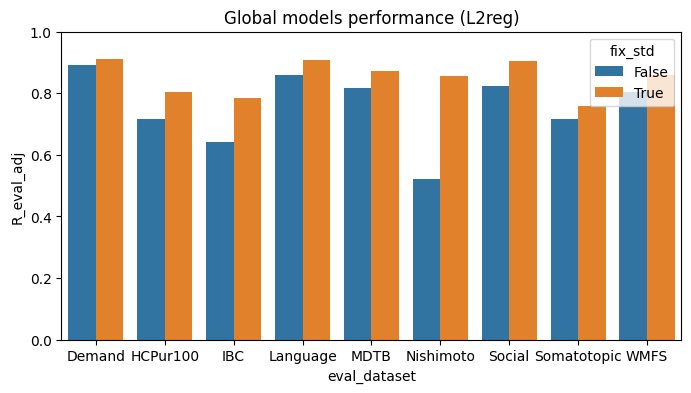

In [6]:
df_summary = (df_best.groupby(['eval_dataset', 'fix_std'], as_index=False)['R_eval_adj'].mean())

plt.figure(figsize=(8,4))
sns.barplot(data=df_summary, x='eval_dataset', y='R_eval_adj', hue='fix_std', errorbar=None)
plt.title(f"Global models performance (L2reg)")
plt.ylim([0, 1]);